In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.patches import FancyBboxPatch

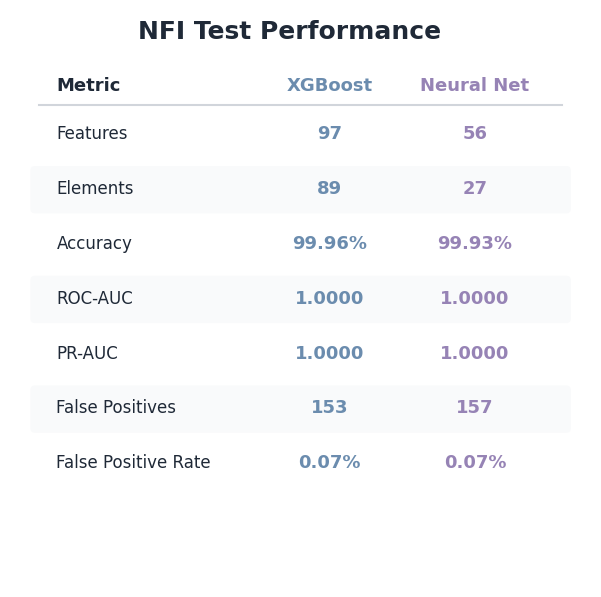

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ---------- Colors ----------
XGB_MUTED_COLOR = '#6B8CAE'    # soft slate blue
NN_MUTED_COLOR  = '#9683B5'    # soft muted purple
INK    = '#1F2937'
ROW_BG = '#F9FAFB'

# ---------- Data ----------
# These values were pulled from the model & eval notebooks as well as the model/eval report.
# (metric label, XGBoost value, Neural Net value)
rows = [
    ('Features',           '97',      '56'),
    ('Elements',           '89',      '27'),
    ('Accuracy',           '99.96%',  '99.93%'),
    ('ROC-AUC',            '1.0000',  '1.0000'),
    ('PR-AUC',             '1.0000',  '1.0000'),
    ('False Positives',    '153',     '157'),
    ('False Positive Rate', '0.07%',  '0.07%'),
]

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Title
ax.text(0.22, 0.95,
        'NFI Test Performance',
        fontsize=18, fontweight='bold', color=INK,
        transform=ax.transAxes)

# Header
header_y = 0.86
ax.text(0.08, header_y, 'Metric',
        fontsize=13, fontweight='bold', color=INK,
        transform=ax.transAxes)
ax.text(0.55, header_y, 'XGBoost',
        fontsize=13, fontweight='bold', color=XGB_MUTED_COLOR,
        ha='center', transform=ax.transAxes)
ax.text(0.80, header_y, 'Neural Net',
        fontsize=13, fontweight='bold', color=NN_MUTED_COLOR,
        ha='center', transform=ax.transAxes)

# Header underline
ax.plot([0.05, 0.95], [header_y - 0.025, header_y - 0.025],
        color='#D1D5DB', linewidth=1.5, transform=ax.transAxes)

# Rows
row_height = 0.095
top_y = header_y - 0.075
for i, (metric, xgb_val, nn_val) in enumerate(rows):
    y = top_y - i * row_height

    # Alternating row backgrounds
    if i % 2 == 1:
        ax.add_patch(FancyBboxPatch(
            (0.04, y - 0.038), 0.92, 0.072,
            boxstyle='round,pad=0.005,rounding_size=0.008',
            facecolor=ROW_BG, edgecolor='none',
            transform=ax.transAxes, zorder=0,
        ))

    ax.text(0.08, y, metric,
            fontsize=12, color=INK, va='center', fontweight='medium',
            transform=ax.transAxes)
    ax.text(0.55, y, xgb_val,
            fontsize=13, color=XGB_MUTED_COLOR, ha='center', va='center',
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.80, y, nn_val,
            fontsize=13, color=NN_MUTED_COLOR, ha='center', va='center',
            fontweight='bold', transform=ax.transAxes)

plt.show()

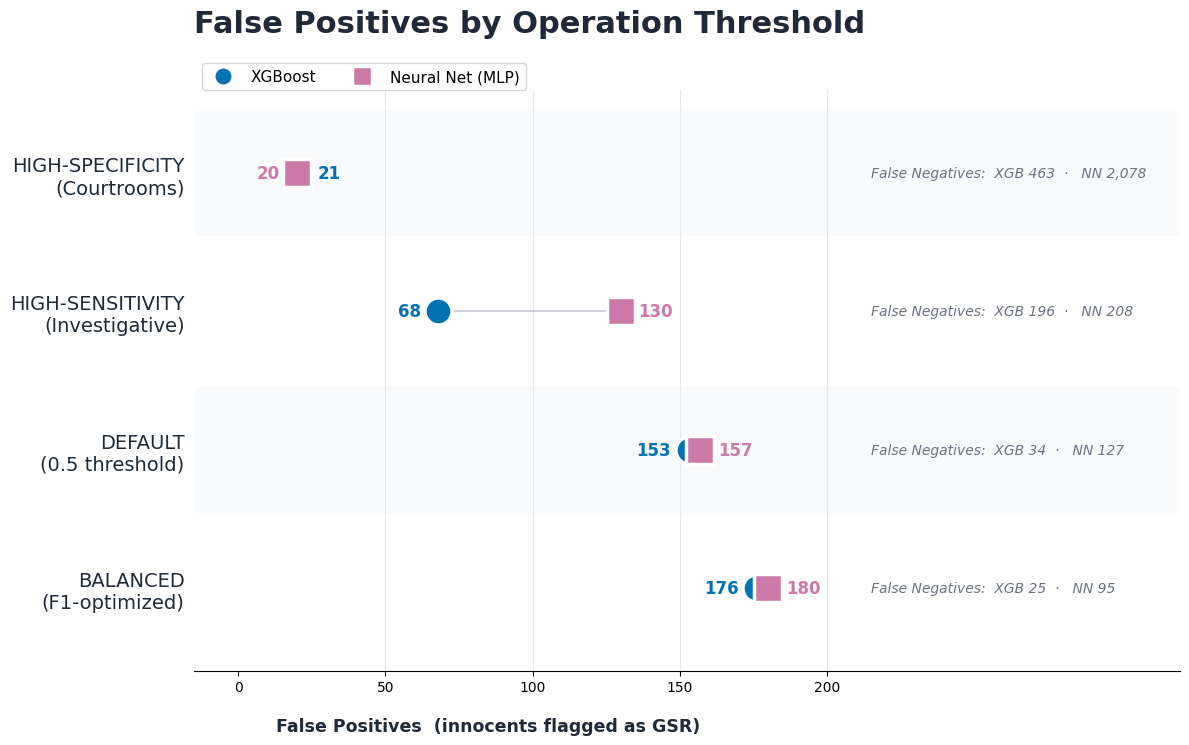

In [7]:
# ---------- Colors ----------
XGB_COLOR = '#0072B2'    # Okabe-Ito vibrant blue
NN_COLOR  = '#CC79A7'    # Okabe-Ito magenta (reddish purple)
MUTED = '#6B7280'
GRID  = '#E5E7EB'


# Operating points sorted by use case priority
# values pulled directly from XGB & NN notebooks
op_points = [
    {
        'name': 'HIGH-SPECIFICITY',
        'use_case': '(Courtrooms)',
        'xgb_thr': 0.9389, 'xgb_fp': 21,  'xgb_fn': 463,
        'nn_thr':  0.9830, 'nn_fp':  20,  'nn_fn':  2078,
    },
    {
        'name': 'HIGH-SENSITIVITY',
        'use_case': '(Investigative)',
        'xgb_thr': 0.7659, 'xgb_fp': 68,  'xgb_fn': 196,
        'nn_thr':  0.6134, 'nn_fp':  130, 'nn_fn':  208,
    },
    {
        'name': 'DEFAULT',
        'use_case': '(0.5 threshold)',
        'xgb_thr': 0.5000, 'xgb_fp': 153, 'xgb_fn': 34,
        'nn_thr':  0.5000, 'nn_fp':  157, 'nn_fn':  127,
    },
    {
        'name': 'BALANCED',
        'use_case': '(F1-optimized)',
        'xgb_thr': 0.4379, 'xgb_fp': 176, 'xgb_fn': 25,
        'nn_thr':  0.4316, 'nn_fp':  180, 'nn_fn':  95,
    },
]
 
fig, ax = plt.subplots(figsize=(12, 9))
 
n_rows = len(op_points)
y_positions = np.arange(n_rows)[::-1]  # top-to-bottom = high-spec first
 
# Alternating row backgrounds for readability
for i, y in enumerate(y_positions):
    if i % 2 == 0:
        ax.axhspan(y - 0.45, y + 0.45, color=ROW_BG, zorder=0)
 
# Plot each operating point
max_fp = max(max(op['xgb_fp'], op['nn_fp']) for op in op_points)
for i, op in enumerate(op_points):
    y = y_positions[i]
 
    # Connecting line between the two model points (under markers)
    ax.plot([op['xgb_fp'], op['nn_fp']], [y, y],
            color='#9CA3AF', linewidth=1.5, alpha=0.5, zorder=1)
 
    # Markers
    ax.scatter(op['xgb_fp'], y, s=380, color=XGB_COLOR, zorder=3,
               edgecolors='white', linewidths=2.5)
    ax.scatter(op['nn_fp'], y, s=380, color=NN_COLOR, zorder=3,
               edgecolors='white', linewidths=2.5, marker='s')
 
    # FP value labels next to each marker with no overlap
    if op['xgb_fp'] < op['nn_fp']:
        # XGB to the left of NN
        ax.text(op['xgb_fp'] - 6, y, str(op['xgb_fp']),
                ha='right', va='center', fontsize=12, fontweight='bold',
                color=XGB_COLOR)
        ax.text(op['nn_fp'] + 6, y, str(op['nn_fp']),
                ha='left', va='center', fontsize=12, fontweight='bold',
                color=NN_COLOR)
    elif op['xgb_fp'] > op['nn_fp']:
        # NN to the left of XGB
        ax.text(op['nn_fp'] - 6, y, str(op['nn_fp']),
                ha='right', va='center', fontsize=12, fontweight='bold',
                color=NN_COLOR)
        ax.text(op['xgb_fp'] + 6, y, str(op['xgb_fp']),
                ha='left', va='center', fontsize=12, fontweight='bold',
                color=XGB_COLOR)
    else:
        # Tied (within rounding)
        ax.text(op['xgb_fp'], y + 0.27, f"{op['xgb_fp']} (XGB) · {op['nn_fp']} (NN)",
                ha='center', va='bottom', fontsize=12, fontweight='bold',
                color=INK)
 
    # False Negative context (far right)
    fn_text = (f"False Negatives:  XGB {op['xgb_fn']:,}  ·   NN {op['nn_fn']:,}")
    ax.text(max_fp + 35, y, fn_text,
            ha='left', va='center', fontsize=10, color=MUTED, style='italic')
 
# Y-axis labels: operating point names + use case
ax.set_yticks(y_positions)
yticklabels = [f"{op['name']}\n{op['use_case']}" for op in op_points]
ax.set_yticklabels(yticklabels, fontsize=14, color=INK)
 
# X-axis
# ax.set_xlabel('False Positives  (innocents flagged as GSR)',
#               fontsize=12.5, color=INK, labelpad=10, fontweight='bold',
#               loc='center')
ax.set_xlabel('False Positives  (innocents flagged as GSR)',
              fontsize=12.5, color=INK, labelpad=10, fontweight='bold')
ax.xaxis.set_label_coords(100 / (max_fp + 140 + 15), -0.08)
ax.set_xlim(-15, max_fp + 140)
ax.set_ylim(-0.6, n_rows - 0.4)
 
# Vertical reference lines at meaningful FP thresholds
for fp_ref, label in [(50, '50'), (100, '100'), (150, '150'), (200, '200')]:
    ax.axvline(fp_ref, color=GRID, linewidth=0.8, zorder=0)
 
ax.set_xticks([0, 50, 100, 150, 200])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.set_axisbelow(True)
 
# Title
ax.set_title(
    'False Positives by Operation Threshold',
    fontsize=22, fontweight='bold', color=INK, loc='left', pad=42,
)
 
# Legend
legend_handles = [
    mlines.Line2D([], [], marker='o', linestyle='None', markersize=14,
                  markerfacecolor=XGB_COLOR, markeredgecolor='white',
                  markeredgewidth=2.5, label='XGBoost'),
    mlines.Line2D([], [], marker='s', linestyle='None', markersize=14,
                  markerfacecolor=NN_COLOR, markeredgecolor='white',
                  markeredgewidth=2.5, label='Neural Net (MLP)'),
]
ax.legend(handles=legend_handles, loc='upper left',
          bbox_to_anchor=(0.0, 1.06),
          fontsize=11, frameon=True, edgecolor='#D1D5DB', framealpha=0.95,
          ncol=2)

plt.tight_layout(rect=(0, 0.05, 1, 0.90))